# **Variational Autoencoders**

Make our VAE model which has the encoder layers, the decoder layers, and a Lambda function that samples from the latent 2-dimensional gaussian distribution, given a mean and variance value. The model also has a custom loss function for determining how closely the synthesized images match the original input.

In [15]:
import keras
from keras import layers, Model, ops
import numpy as np

latent_dim = 2

# ----- Encoder -----
encoder_input = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_input)
x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation='relu')(x)

z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

# Stack mean and log_var so we can use them as a model output for the KL loss
kl_params = layers.Concatenate(name='kl_params')([z_mean, z_log_var])

# ----- Sampling (reparameterization trick) -----
def sample(args):
    z_mean, z_log_var = args
    epsilon = keras.random.normal(shape=ops.shape(z_mean))
    return z_mean + ops.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sample, name='z')([z_mean, z_log_var])

# ----- Decoder (built as its own Model) -----
decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation='relu')(decoder_input)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
decoder_output = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
decoder = Model(decoder_input, decoder_output, name='decoder')

# ----- Full VAE: encoder -> sampling -> decoder -----
reconstruction = decoder(z)
# Rename the output so we can refer to it in compile()
reconstruction = layers.Lambda(lambda t: t, name='reconstruction')(reconstruction)

vae = Model(encoder_input, [reconstruction, kl_params])

# ----- Loss functions -----
def kl_loss_fn(y_true, y_pred):
    z_mean = y_pred[:, :latent_dim]
    z_log_var = y_pred[:, latent_dim:]
    return -0.5 * ops.mean(
        1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var)
    )

# We sum over pixel error rather than averaging... this gives a lot more weight to the image output
# than to the KL divergence.
def reconstruction_loss_fn(y_true, y_pred):
    bce = keras.losses.binary_crossentropy(y_true, y_pred)  # shape: (batch, 28, 28)
    return ops.mean(ops.sum(bce, axis=(1, 2)))              # sum over pixels, mean over batch

vae.compile(
    optimizer='adam',
    loss={'reconstruction': reconstruction_loss_fn,
          'kl_params': kl_loss_fn}
)

Now we can train our model on the MNIST dataset.

In [16]:
import numpy as np
from keras import datasets

(x_train, _), (x_test, _) = datasets.mnist.load_data()
mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

# Training: pass the input image as the target for reconstruction,
# and a dummy zero tensor as the "target" for the KL output (it's ignored)
dummy_kl_target = np.zeros((len(mnist_digits), latent_dim * 2))
vae.fit(mnist_digits, {'reconstruction': mnist_digits, 'kl_params': dummy_kl_target},
        epochs=30, batch_size=128)

Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - kl_params_loss: 2.5404 - loss: 211.9716 - reconstruction_loss: 209.4255
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - kl_params_loss: 3.7108 - loss: 175.3075 - reconstruction_loss: 171.5943
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_params_loss: 3.7314 - loss: 164.8739 - reconstruction_loss: 161.1425
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - kl_params_loss: 3.7924 - loss: 161.1339 - reconstruction_loss: 157.3412
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_params_loss: 3.8267 - loss: 158.8462 - reconstruction_loss: 155.0189
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_params_loss: 3.8392 - loss: 157.2033 - reconstruction_loss: 153.3645
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_params_loss: 3.8450 - loss: 156.0528 - reconstruction_loss: 152.2079
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_params_loss: 3.8519 - loss: 155.1469 - reconstruction_loss:

We are now going to move through the latent space and spit out images at many points as we progress...

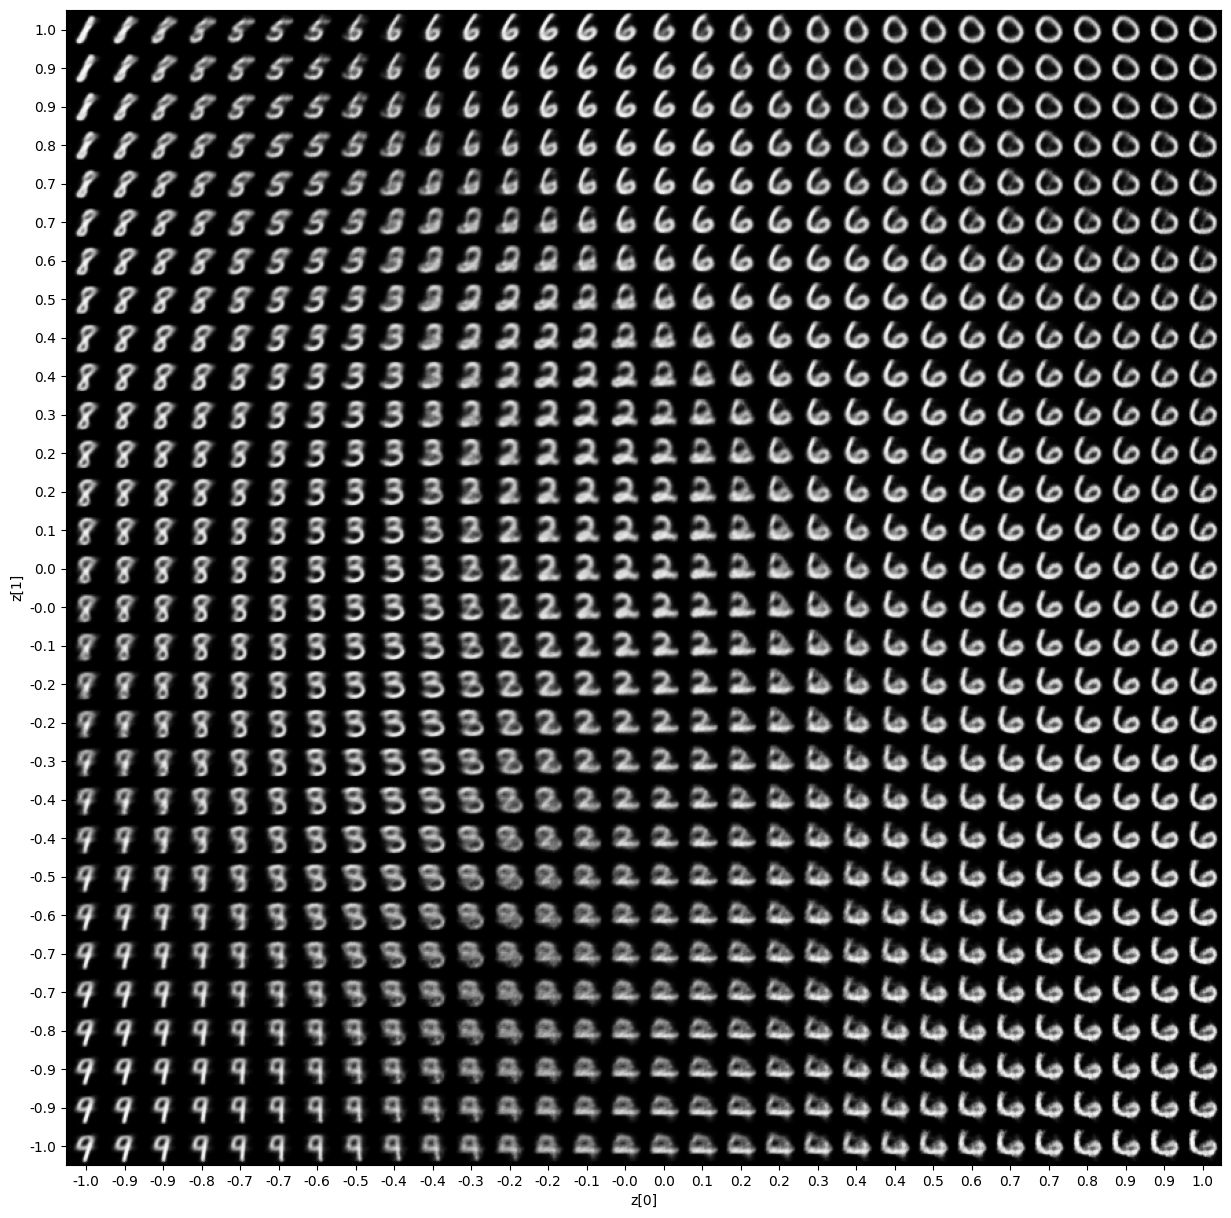

In [17]:
import matplotlib.pyplot as plt

n = 30
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-1, 1, n)
grid_y = np.linspace(-1, 1, n)[::-1]

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[
            i * digit_size : (i + 1) * digit_size,
            j * digit_size : (j + 1) * digit_size,
        ] = digit

plt.figure(figsize=(15, 15))
start_range = digit_size // 2
end_range = n * digit_size + start_range
pixel_range = np.arange(start_range, end_range, digit_size)
sample_range_x = np.round(grid_x, 1)
sample_range_y = np.round(grid_y, 1)
plt.xticks(pixel_range, sample_range_x)
plt.yticks(pixel_range, sample_range_y)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.imshow(figure, cmap="Greys_r")
plt.show()